In [5]:
import numpy as np
import os
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from keras.applications import ResNet50
# from tensorflow.keras.applications.resnet50 import preprocess_input 
from keras.applications.resnet import preprocess_input 
from keras.models import Model
from keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Resizing,
    Lambda,
    GlobalAveragePooling2D,
    Dense,
    Dropout
) 
from keras.regularizers import l2 
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.utils import to_categorical
from collections import Counter

In [ ]:

npz_folder = 'Amphibia/NPX_1/'
X_list, y_list = [], []
for file in tqdm(os.listdir(npz_folder)):
    if file.endswith('.npz'):
        try:
            data = np.load(os.path.join(npz_folder, file))
            spec = data['spec']
            label = data['label'].item()
            if spec.shape == (1025, 313):
                X_list.append(spec)
                y_list.append(label)
        except Exception:
            continue
print(f"Espectrogramas válidos cargados: {len(X_list)}")

# Normalizar y añadir canal
arr = np.stack(X_list)[..., np.newaxis].astype('float32')
X = arr / np.max(arr)

y = np.array(y_list)
# Filtrar clases con menos de 2 ejemplos (opcional)
counts = Counter(y)
valid = [lab for lab, cnt in counts.items() if cnt >= 2]
mask = np.isin(y, valid)
X, y = X[mask], y[mask]

# Encode de etiquetas
e = LabelEncoder()
y_enc = e.fit_transform(y)
num_classes = len(e.classes_)
y_cat = to_categorical(y_enc, num_classes)

# np.save('models/Amphibia/classes.npy', e.classes_) 

# Split entrenamiento/validación
X_train, X_val, y_train, y_val, y_train_enc, y_val_enc = train_test_split(
    X, y_cat, y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42
)


100%|██████████| 3513/3513 [03:54<00:00, 14.95it/s]


Espectrogramas válidos cargados: 3495


In [ ]:
# MANEJO DE DESBALANCE: PESOS DE CLASE (Para las clases minoritarias Ronaldin)
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=y_train_enc
)
class_weight = dict(enumerate(cw))
print("Pesos de clase:", class_weight)

# DEFINIR MODELO: CAPAS INICIALES + RESNET
input_layer = Input(shape=(1025, 313, 1), name='input_spec')
# Extracción inicial
x = Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4))(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.2)(x)

x = Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.25)(x)

# Preprocesamiento para ResNet
# x = Resizing(224, 224)(x)
# x = Lambda(lambda z: tf.repeat(z, repeats=3, axis=-1))(x)
# x = Lambda(preprocess_input)(x)

# Convertir feature maps a 3 canales con convolución 1x1
x = Conv2D(3, (1,1), activation='linear', padding='same', name='to_3ch')(x)
# Redimensionar a tamaño ResNet
x = Resizing(224, 224, name='resize')(x)
# Preprocesar según ResNet
x = preprocess_input(x)


# Cargar ResNet50
base = ResNet50(include_top=False, weights='imagenet', input_shape=(224,224,3))
x = base(x)

# Cabeza de clasificación
y = GlobalAveragePooling2D()(x)
y = Dropout(0.5)(y)
y = Dense(num_classes, activation='softmax')(y)

model = Model(inputs=input_layer, outputs=y)
model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)
model.summary()


Pesos de clase: {0: 0.38248974008207937, 1: 1.3481195756991322, 2: 0.39727195225916456, 3: 0.41743804120633027, 4: 5.139705882352941, 5: 1.3053221288515406, 6: 41.11764705882353, 7: 2.652751423149905, 8: 0.9562243502051984, 9: 2.005738880918221, 10: 0.6969092721834497, 11: 9.137254901960784, 12: 3.426470588235294, 13: 1.581447963800905, 14: 0.530550284629981, 15: 0.2797118847539016, 16: 3.426470588235294, 17: 3.16289592760181, 18: 0.4646061814556331, 19: 0.27782193958664547, 20: 4.568627450980392, 21: 1.495187165775401, 22: 4.1117647058823525, 23: 16.44705882352941, 24: 6.32579185520362, 25: 6.32579185520362, 26: 5.139705882352941, 27: 10.279411764705882, 28: 0.38248974008207937, 29: 10.279411764705882, 30: 1.713235294117647, 31: 0.7213622291021672, 32: 3.045751633986928, 33: 0.5791217895608948}
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_spec (InputLayer)     [(None, 1025, 313

In [ ]:

# =====================================================================
# CALLBACKS
# =====================================================================
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('Mammalia/best_model_M2.h5', save_best_only=True, verbose=1)
]

# =====================================================================
# ENTRENAMIENTO
# =====================================================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/50


2025-07-27 08:11:14.704866: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-07-27 08:11:15.539643: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-27 08:11:15.539699: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 1, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-27 08:11:15.539741: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 40595 MB memory) -> physical PluggableDevice (device: 0, name: DML, pci bus id: <undefined>)
2025-07-27 08:11:15.539758: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_f

59/59 [==============================] - ETA: 0s - loss: 1.8935 - accuracy: 0.3025 - precision: 0.4835 - recall: 0.1259 - auc: 0.7518

2025-07-27 08:11:52.106122: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-07-27 08:11:52.382654: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-27 08:11:52.382706: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 1, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-27 08:11:52.382746: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 40595 MB memory) -> physical PluggableDevice (device: 0, name: DML, pci bus id: <undefined>)
2025-07-27 08:11:52.382766: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_f


Epoch 1: val_loss improved from inf to 1.82161, saving model to Mammalia/best_model_M2.h5
59/59 [==============================] - 43s 532ms/step - loss: 1.8935 - accuracy: 0.3025 - precision: 0.4835 - recall: 0.1259 - auc: 0.7518 - val_loss: 1.8216 - val_accuracy: 0.0987 - val_precision: 0.0987 - val_recall: 0.0987 - val_auc: 0.8026
Epoch 2/50
59/59 [==============================] - ETA: 0s - loss: 1.0837 - accuracy: 0.4564 - precision: 0.6022 - recall: 0.2885 - auc: 0.8457
Epoch 2: val_loss improved from 1.82161 to 1.43443, saving model to Mammalia/best_model_M2.h5
59/59 [==============================] - 24s 401ms/step - loss: 1.0837 - accuracy: 0.4564 - precision: 0.6022 - recall: 0.2885 - auc: 0.8457 - val_loss: 1.4344 - val_accuracy: 0.3262 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.8373
Epoch 3/50
59/59 [==============================] - ETA: 0s - loss: 0.5722 - accuracy: 0.5253 - precision: 0.6207 - recall: 0.3929 - auc: 0.8969
Epoch 3: val_loss did not

2025-07-27 08:31:22.621834: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


8/8 [==============================] - 3s 178ms/step
Classification Report:
                      precision    recall  f1-score   support

 Alouatta_seniculus       0.79      1.00      0.88        23
Bradypus_variegatus       0.20      1.00      0.33         1
    Cerdocyon_thous       0.00      0.00      0.00         1
 Lontra_longicaudis       1.00      1.00      1.00         9
      Panthera_onca       0.92      0.85      0.88        13
      Pecari_tajacu       0.12      1.00      0.22         1
      Procyon_lotor       0.97      0.88      0.92       163
      Puma_concolor       0.89      1.00      0.94        17
Sciurus_granatensis       1.00      0.80      0.89         5

           accuracy                           0.90       233
          macro avg       0.66      0.84      0.68       233
       weighted avg       0.94      0.90      0.91       233

Balanced Accuracy: 0.8359393844056421
PR-AUC Macro: 0.9196550830778464
MCC: 0.8152153818220819
Entrenamiento completado y encod

2025-07-27 08:31:24.979762: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-27 08:31:24.979815: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 1, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-27 08:31:24.979854: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 40595 MB memory) -> physical PluggableDevice (device: 0, name: DML, pci bus id: <undefined>)
2025-07-27 08:31:24.979871: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:1 with 29933 MB memory) -> physical PluggableDevice (device: 1, name: 

In [ ]:
model.load_weights('models\\Amphibia\\model_M1.h5') # Aca la ram llega al tope, entonces trata de noi terner nada de fondo

: 

In [ ]:
# EVALUACIÓN SOBRE TEST 
# Supón que separaste un X_test, y_test_enc, y_test si lo necesitas
y_test_cat = to_categorical(y_val_enc, num_classes)
y_score = model.predict(X_val)
y_pred = np.argmax(y_score, axis=1)

print("Classification Report:\n", classification_report(y_val_enc, y_pred, target_names=e.classes_))
print("Balanced Accuracy:", balanced_accuracy_score(y_val_enc, y_pred))
y_bin = label_binarize(y_val_enc, classes=range(num_classes))
print("PR-AUC Macro:", average_precision_score(y_bin, y_score, average='macro'))
print("MCC:", matthews_corrcoef(y_val_enc, y_pred))

# # Guardar clases para inferencia
# np.save('classes.npy', e.classes_)
# print("Entrenamiento completado y encoder guardado.")

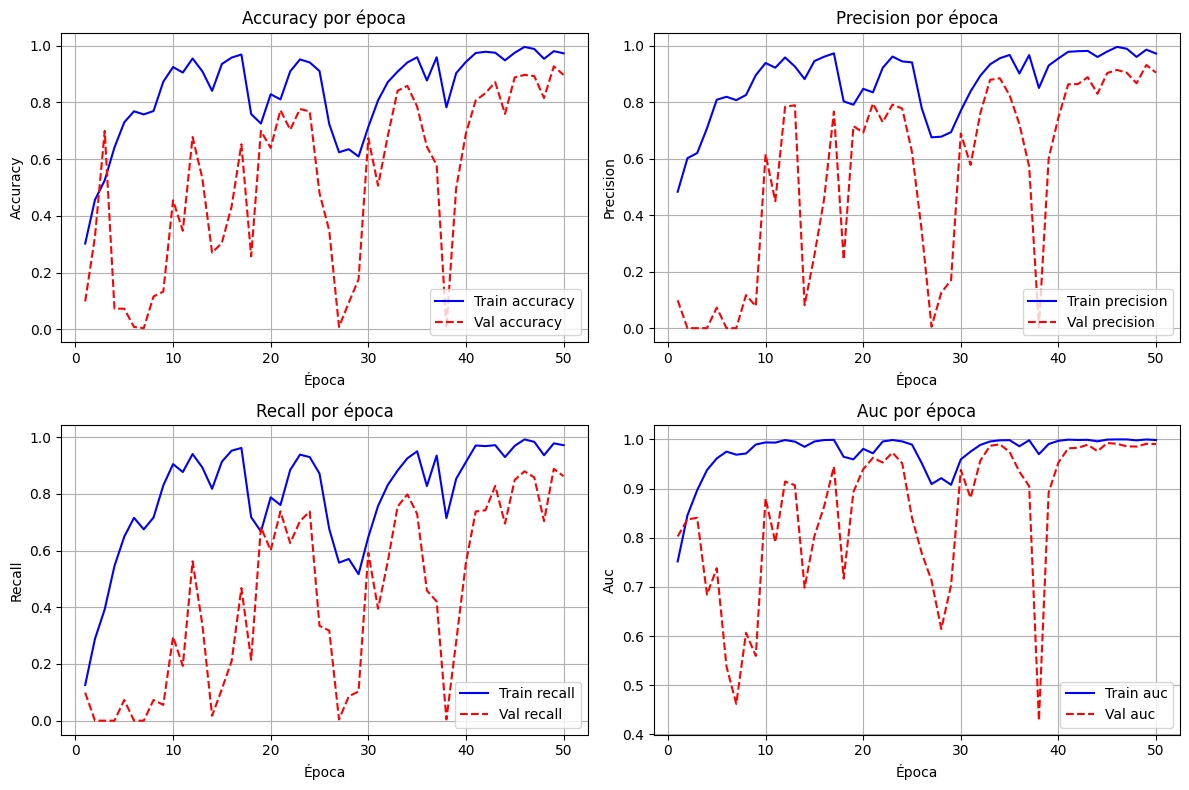

8/8 [==============================] - 1s 182ms/step


<Figure size 800x800 with 0 Axes>

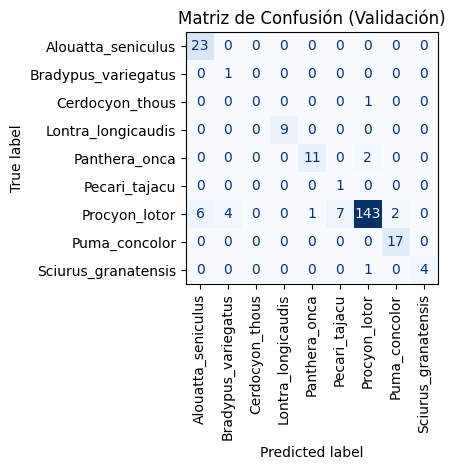

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- 1) Curvas de entrenamiento/validación -----------------------------
# history es el objeto devuelto por model.fit
metrics = ['accuracy', 'precision', 'recall', 'auc']
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(12, 8))
for i, m in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.plot(epochs, history.history[m],   'b-', label=f'Train {m}')
    plt.plot(epochs, history.history[f'val_{m}'], 'r--', label=f'Val {m}')
    plt.title(f'{m.capitalize()} por época')
    plt.xlabel('Época')
    plt.ylabel(m.capitalize())
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()


# --- 2) Matriz de confusión final ---------------------------------------
# Predecimos sobre X_val
y_score_val = model.predict(X_val)
y_pred_val  = np.argmax(y_score_val, axis=1)

# Calculamos la matriz
cm = confusion_matrix(y_val_enc, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=e.classes_)

plt.figure(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title('Matriz de Confusión (Validación)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1) Predecir sobre X_val
y_score_val = model.predict(X_val)
y_pred_val  = np.argmax(y_score_val, axis=1)

# 2) Calcular la matriz de confusión
cm = confusion_matrix(y_val_enc, y_pred_val)
labels = e.classes_

# 3) Normalizar por filas para ver porcentaje de aciertos por clase
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 4) Dibujar el heatmap anotado
plt.figure(figsize=(10, 10))
im = plt.imshow(cm_norm, interpolation='nearest')
plt.title('Matriz de Confusión Normalizada\n(Validación)')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.xticks(np.arange(len(labels)), labels, rotation=90)
plt.yticks(np.arange(len(labels)), labels)

# Añadir colorbar
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel('Proporción por fila', rotation=-90, va="bottom")

# Anotar cada celda con el valor normalizado y el conteo bruto
thresh = cm_norm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            f"{cm_norm[i, j]:.2f}\n({cm[i, j]})",
            ha="center", va="center",
            color="white" if cm_norm[i, j] > thresh else "black",
            fontsize=8
        )

plt.tight_layout()
plt.show()


NameError: name 'model' is not defined